Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt

Jacobi (edited to have error tracking)

In [2]:
def jacobi(A, b, x0, tol, max_iterations):
    n = len(b)
    x = x0.copy()
    errors = []

    for k in range(max_iterations):
        x_new = np.zeros_like(x)
        
        for i in range(n):
            s = sum(A[i][j] * x[j] for j in range(n) if j != i)
            x_new[i] = (b[i] - s) / A[i][i]
            
        error = np.linalg.norm(x_new - x, ord=np.inf)
        errors.append(error)
            
        # Check for convergence
        if np.linalg.norm(x_new - x, ord=np.inf) < tol:
            return x_new, k, errors
        
        x = x_new
        
    return x, max_iterations, errors

Gauss-Seidel (edited to have error tracking)

In [3]:
def gauss_seidel(A, b, x0, tol, max_iterations):
    n = len(b)
    x = x0.copy()
    errors = []

    for k in range(max_iterations):
        x_new = x.copy()
        
        for i in range(n):
            s1 = sum(A[i][j] * x_new[j] for j in range(i)) # Using already updated values
            s2 = sum(A[i][j] * x[j] for j in range(i + 1, n)) # Using old values
            x_new[i] = (b[i] - s1 - s2) / A[i][i]
        
        error = np.linalg.norm(x_new - x, ord=np.inf)
        errors.append(error)
        
        # Check for convergence
        if np.linalg.norm(x_new - x, ord=np.inf) < tol:
            return x_new, k, errors
        
        x = x_new
        
    return x, max_iterations, errors

Setting up matrix from system of equations

In [4]:
A = np.array([
    [3, -0.1, -0.2],
    [0.1, 7, -0.3],
    [0.3, -0.2, 10]
], dtype=float)
b = np.array([7.85, -19.3, 71.4])

Using Jacobi with tolerance 10^-3

In [5]:
x0 = np.array([0.0, 0.0, 0.0])
tol = 1e-3
max_iterations = 100

solution, iterations, jacobi_errors = jacobi(A, b, x0, tol, max_iterations)

print(f"Solution: {solution}")
print(f"Iterations: {iterations}")

Solution: [ 3.0000225  -2.50000266  6.99998104]
Iterations: 3


Using Gauss-Seidel with tolerance 10^-3

In [6]:
x0 = np.array([0.0, 0.0, 0.0])
tol = 1e-3
max_iterations = 100

solution, iterations, gs_errors = gauss_seidel(A, b, x0, tol, max_iterations)

print(f"Gauss-Seidel Solution: {solution}")
print(f"Iterations: {iterations}")

Gauss-Seidel Solution: [ 3.00000035 -2.50000004  6.99999999]
Iterations: 3


Plotting error for tolerance 10^-3

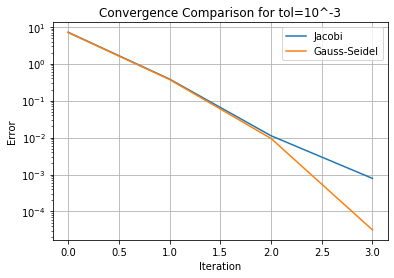

In [7]:
plt.figure()
plt.semilogy(jacobi_errors, label="Jacobi")
plt.semilogy(gs_errors, label="Gauss-Seidel")

plt.xlabel("Iteration")
plt.ylabel("Error")
plt.title("Convergence Comparison for tol=10^-3")
plt.legend()
plt.grid()
plt.show()

Using Jacobi with tolerance 10^-6

In [8]:
x0 = np.array([0.0, 0.0, 0.0])
tol = 1e-6
max_iterations = 100

solution, iterations, jacobi_errors = jacobi(A, b, x0, tol, max_iterations)

print(f"Solution: {solution}")
print(f"Iterations: {iterations}")

Solution: [ 3.  -2.5  7. ]
Iterations: 6


Using Gauss-Seidel with tolerance 10^-6

In [9]:
x0 = np.array([0.0, 0.0, 0.0])
tol = 1e-6
max_iterations = 100

solution, iterations, gs_errors = gauss_seidel(A, b, x0, tol, max_iterations)

print(f"Gauss-Seidel Solution: {solution}")
print(f"Iterations: {iterations}")

Gauss-Seidel Solution: [ 3.  -2.5  7. ]
Iterations: 4


Plotting error for tolerance 10^-6

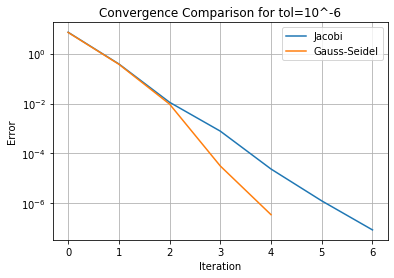

In [10]:
plt.figure()
plt.semilogy(jacobi_errors, label="Jacobi")
plt.semilogy(gs_errors, label="Gauss-Seidel")

plt.xlabel("Iteration")
plt.ylabel("Error")
plt.title("Convergence Comparison for tol=10^-6")
plt.legend()
plt.grid()
plt.show()

Using Jacobi with tolerance 10^-9

In [11]:
x0 = np.array([0.0, 0.0, 0.0])
tol = 1e-9
max_iterations = 100

solution, iterations, jacobi_errors = jacobi(A, b, x0, tol, max_iterations)

print(f"Solution: {solution}")
print(f"Iterations: {iterations}")

Solution: [ 3.  -2.5  7. ]
Iterations: 8


Using Gauss-Seidel with tolerance 10^-9

In [12]:
x0 = np.array([0.0, 0.0, 0.0])
tol = 1e-9
max_iterations = 100

solution, iterations, gs_errors = gauss_seidel(A, b, x0, tol, max_iterations)

print(f"Gauss-Seidel Solution: {solution}")
print(f"Iterations: {iterations}")

Gauss-Seidel Solution: [ 3.  -2.5  7. ]
Iterations: 6


Plotting error for tolerance 10^-9

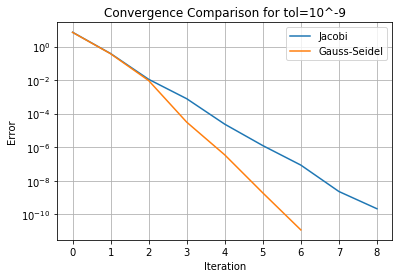

In [13]:
plt.figure()
plt.semilogy(jacobi_errors, label="Jacobi")
plt.semilogy(gs_errors, label="Gauss-Seidel")

plt.xlabel("Iteration")
plt.ylabel("Error")
plt.title("Convergence Comparison for tol=10^-9")
plt.legend()
plt.grid()
plt.show()

For 10^-3, 10^-6, and 10^-9 tolerances, Jacobi took 3, 6, and 8 iterations respectively while Gauss-Seidel took 3, 4, and 6 iterations respectively. Notice that for both algorithms, a lower tolerance results in more iterations needed to converge. Also notice that at every tolerance, Gauss-Seidel performed as good or better than the Jacobi method. Both Jacobi and Gauss-Seidel each took more iterations to converge to a finer tolerance, but Gauss-Seidel always took as many or less iterations than Jacobi. A finer tolerance requires more iterations to converge. From the plots, Gauss-Seidel can be seen to always have an error less than or equal to Jacobi and to always converge in as many or less iterations that Jacobi. Additionally, by comparing the three plots you can see that more iterations (x-axis) are required for finer tolerances.